<a href="https://colab.research.google.com/github/Shakiba-Fatima/Project/blob/main/practice_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Cell 1 — Install Libraries

In [1]:
!pip install xgboost scikit-learn pandas matplotlib seaborn

In [3]:
from google.colab import files
uploaded = files.upload()

Saving final_fraud_dataset.csv to final_fraud_dataset.csv


In [20]:
print("="*50)
print("FULL DATA DIAGNOSIS")
print("="*50)

print("\n1. Shape:", df.shape)
print("\n2. Fraud distribution:")
print(df['is_fraud'].value_counts())
print("Fraud %:", round(df['is_fraud'].mean()*100, 4), "%")

print("\n3. All column stats:")
print(df.describe())

print("\n4. Fraud vs Non-Fraud feature averages:")
print(df.groupby('is_fraud').mean())

print("\n5. Any nulls:")
print(df.isnull().sum())

print("\n6. Sample FRAUD rows:")
print(df[df['is_fraud']==1].head(10))

print("\n7. Sample NON-FRAUD rows:")
print(df[df['is_fraud']==0].head(10))

FULL DATA DIAGNOSIS

1. Shape: (67510, 10)

2. Fraud distribution:
is_fraud
0    67441
1       69
Name: count, dtype: int64
Fraud %: 0.1022 %

3. All column stats:
           Quantity     UnitPrice       Country        amount          hour  \
count  67510.000000  67510.000000  67510.000000  67510.000000  67510.000000   
mean      15.517094      3.387940     33.051222     25.596152     12.590490   
std       64.344131     14.844615      6.381144     89.941447      2.376402   
min        1.000000      0.001000      0.000000      0.001000      7.000000   
25%        2.000000      1.250000     35.000000      7.950000     11.000000   
50%        6.000000      1.950000     35.000000     15.000000     13.000000   
75%       12.000000      3.750000     35.000000     20.400000     14.000000   
max     4300.000000   2033.100000     36.000000   6539.400000     20.000000   

        day_of_week  transaction_count    avg_amount  amount_deviation  \
count  67510.000000       67510.000000  67510.0000

✅ Cell 2 — Import Libraries & Load Data


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_fraud_dataset.csv')
print(df.head())
print(df.columns.tolist())
print(df.shape)

   InvoiceNo StockCode                         Description  Quantity  \
0     559661     21658                  GLASS  BEURRE DISH         8   
1     544838     22363                GLASS JAR MARMALADE          6   
2     563091     22424              ENAMEL BREAD BIN CREAM         1   
3     573028     22144      CHRISTMAS CRAFT LITTLE FRIENDS         6   
4     550328     22055  MINI CAKE STAND  HANGING STRAWBERY         2   

           InvoiceDate  UnitPrice  CustomerID         Country  amount  hour  \
0  2011-07-11 13:22:00       3.95     18061.0  United Kingdom   31.60    13   
1  2011-02-24 10:34:00       2.95     12565.0    Saudi Arabia   17.70    10   
2  2011-08-11 17:02:00      12.75     12994.0  United Kingdom   12.75    17   
3  2011-10-27 13:29:00       2.10     16847.0  United Kingdom   12.60    13   
4  2011-04-17 13:18:00       1.65     17582.0  United Kingdom    3.30    13   

   day_of_week  transaction_count  avg_amount  amount_deviation  is_fraud  
0            0  

✅ Cell 3 — Prepare Features & Target (your dataset is already preprocessed, so we skip date/ID steps)


In [21]:
# Drop non-predictive columns
drop_cols = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode Country
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'].astype(str))

print("Columns:", df.columns.tolist())
print("Fraud cases:", df['is_fraud'].sum())
print("Non-fraud cases:", (df['is_fraud']==0).sum())
print("\nFeature stats by class:")
print(df.groupby('is_fraud').mean().T)

Columns: ['Quantity', 'UnitPrice', 'Country', 'amount', 'hour', 'day_of_week', 'transaction_count', 'avg_amount', 'amount_deviation', 'is_fraud']
Fraud cases: 69
Non-fraud cases: 67441

Feature stats by class:
is_fraud                    0           1
Quantity            15.522175   10.550725
UnitPrice            3.388325    3.011159
Country             27.283136   26.072464
amount              25.604897   17.048406
hour                12.590783   12.304348
day_of_week          2.552246    2.550725
transaction_count  212.718495  648.956522
avg_amount          25.666791   18.555664
amount_deviation    13.639474   10.245839


✅ Cell 4 — Encode Categorical Columns


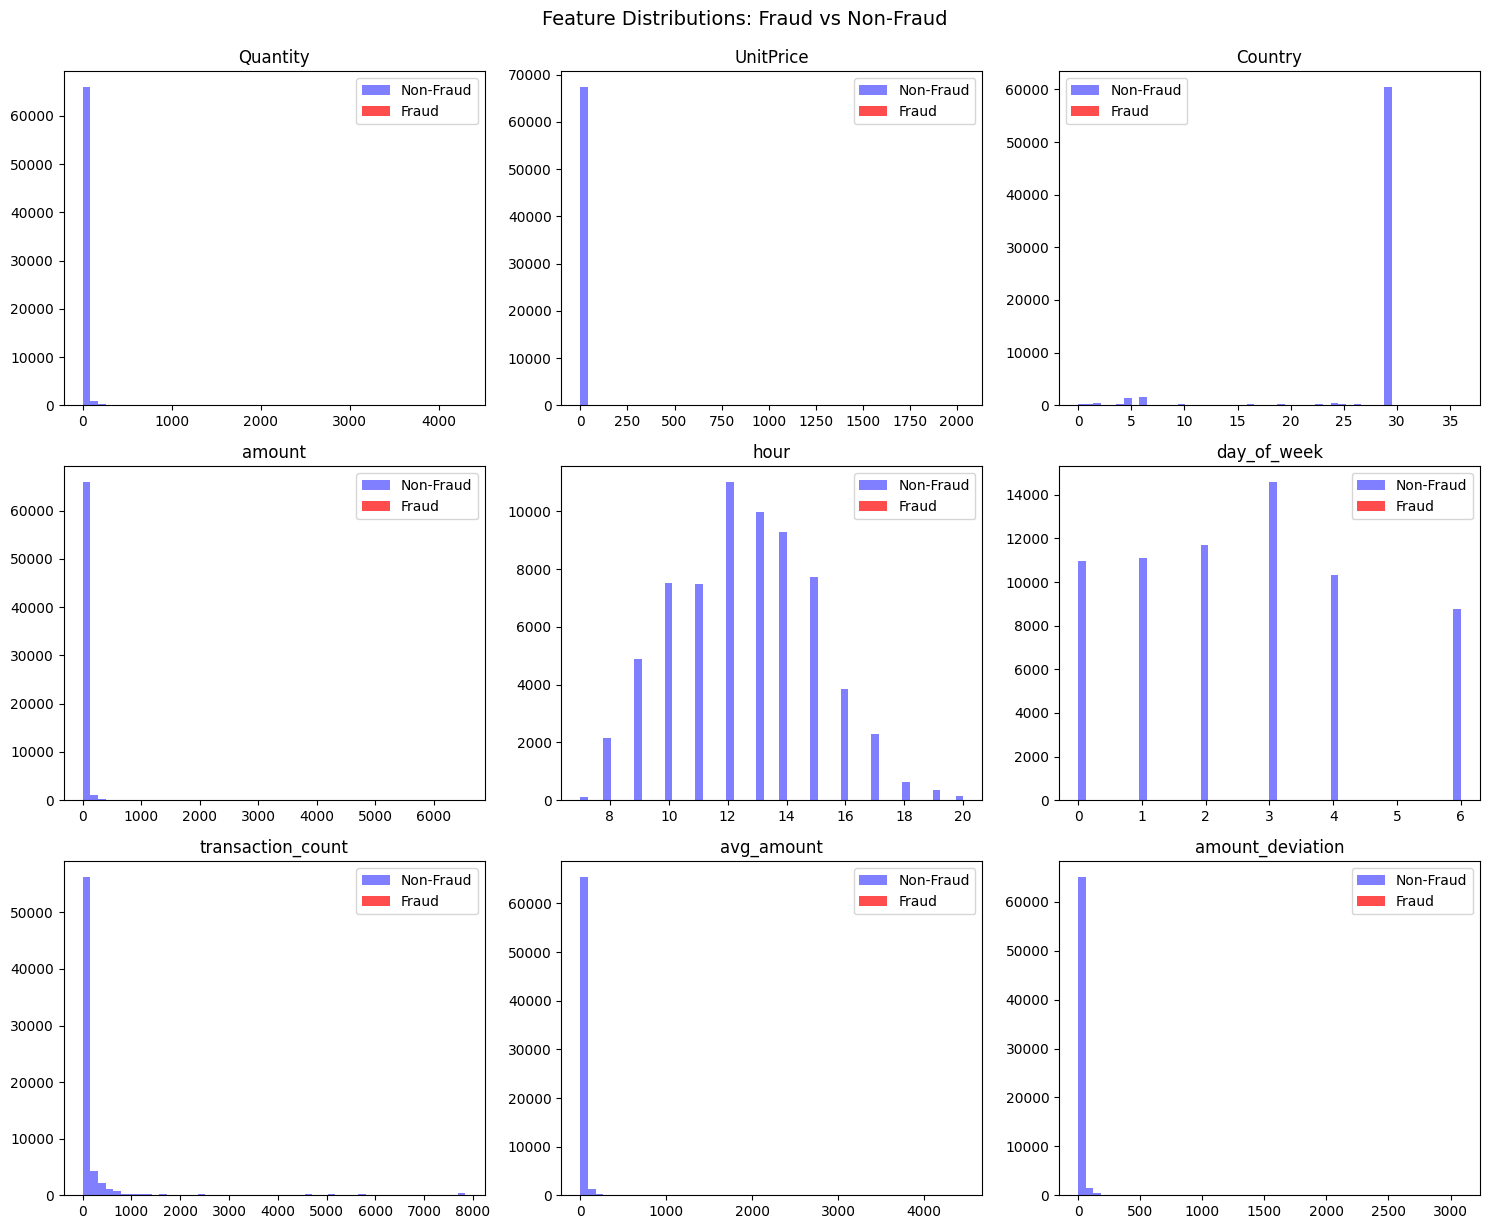

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [c for c in df.columns if c != 'is_fraud']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features[:9]):
    fraud_vals = df[df['is_fraud']==1][col]
    nonfraud_vals = df[df['is_fraud']==0][col]
    axes[i].hist(nonfraud_vals, bins=50, alpha=0.5, label='Non-Fraud', color='blue')
    axes[i].hist(fraud_vals, bins=50, alpha=0.7, label='Fraud', color='red')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Feature Distributions: Fraud vs Non-Fraud", y=1.02, fontsize=14)
plt.show()

In [15]:
print("Total rows:", len(df))
print("Fraud cases:", df['is_fraud'].sum())
print("Non-fraud cases:", (df['is_fraud'] == 0).sum())
print("Fraud percentage:", round(df['is_fraud'].sum() / len(df) * 100, 4), "%")
print("\nFraud sample rows:")
print(df[df['is_fraud'] == 1].head(10))

Total rows: 67510
Fraud cases: 69
Non-fraud cases: 67441
Fraud percentage: 0.1022 %

Fraud sample rows:
      Quantity  UnitPrice  Country  amount  hour  day_of_week  \
1926        16       0.83        0   13.28    12            4   
2703         1       1.45       13    1.45     8            3   
3758         2       0.42       35    0.84    17            0   
4066         1       0.83       35    0.83    14            1   
5409        24       2.55       35   61.20     9            0   
5430         2       1.65       35    3.30    12            6   
5576         8       3.75       35   30.00    12            4   
6675        27       1.45       35   39.15    12            1   
8053        12       1.25       35   15.00    10            4   
9258        12       1.65       35   19.80    14            1   

      transaction_count  avg_amount  amount_deviation  is_fraud  
1926                 50   16.122800          2.842800         1  
2703                 23    3.195652          1.7

✅ Cell 5 — Train-Test Split


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Separate fraud and non-fraud
X_fraud = X[y==1]
y_fraud = y[y==1]
X_nonfraud = X[y==0]
y_nonfraud = y[y==0]

print("Total fraud:", len(X_fraud))
print("Total non-fraud:", len(X_nonfraud))

# Split non-fraud only, keep ALL fraud in train
X_nf_train, X_nf_test, y_nf_train, y_nf_test = train_test_split(
    X_nonfraud, y_nonfraud, test_size=0.2, random_state=42
)

# Use 80% fraud in train, 20% in test
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42
)

import pandas as pd
X_train = pd.concat([X_nf_train, X_f_train])
y_train = pd.concat([y_nf_train, y_f_train])
X_test = pd.concat([X_nf_test, X_f_test])
y_test = pd.concat([y_nf_test, y_f_test])

print("\nTrain fraud:", y_train.sum())
print("Test fraud:", y_test.sum())

Total fraud: 69
Total non-fraud: 67441

Train fraud: 55
Test fraud: 14


✅ Cell 6 — Class Weight & Train XGBoost


In [24]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

fraud_count = y_train.sum()
print("Fraud in train:", fraud_count)

if fraud_count >= 2:
    k = min(fraud_count - 1, 5)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print("After SMOTE - Fraud:", y_train_sm.sum())
    print("After SMOTE - Non-Fraud:", (y_train_sm==0).sum())
else:
    X_train_sm, y_train_sm = X_train, y_train
    print("Not enough fraud for SMOTE, using original data")

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    scale_pos_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train_sm, y_train_sm)
print("Training complete!")

Fraud in train: 55
After SMOTE - Fraud: 53952
After SMOTE - Non-Fraud: 53952
Training complete!


✅ Cell 7 — Predict & Apply Threshold


In [25]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

print("Probability stats for FRAUD rows:")
print(y_prob[y_test==1])
print("\nProbability stats for NON-FRAUD rows (sample):")
print(y_prob[y_test==0][:10])

# Find best threshold
thresholds = np.arange(0.01, 0.99, 0.01)
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    if preds.sum() > 0:
        f1 = f1_score(y_test, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

print(f"\nBest Threshold: {best_thresh}")
print(f"Best F1 Score for Fraud: {best_f1}")

y_pred = (y_prob >= best_thresh).astype(int)

Probability stats for FRAUD rows:
[0.64270616 0.49819043 0.43276885 0.19935824 0.590578   0.16559114
 0.09244169 0.37704378 0.42070007 0.29500705 0.39902735 0.43202016
 0.5067569  0.19032   ]

Probability stats for NON-FRAUD rows (sample):
[0.09843118 0.15384398 0.60573375 0.61102825 0.6306231  0.6046337
 0.6665779  0.6517424  0.39589134 0.46140018]

Best Threshold: 0.64
Best F1 Score for Fraud: 0.002635046113306983


✅ Cell 8 — Evaluation Metrics


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

try:
    print("ROC-AUC:", roc_auc_sc ore(y_test, y_prob))
except:
    print("ROC-AUC: Cannot compute - only one class in test set")

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     13489
           1       0.00      0.07      0.00        14

    accuracy                           0.94     13503
   macro avg       0.50      0.51      0.49     13503
weighted avg       1.00      0.94      0.97     13503

Confusion Matrix:
[[12745   744]
 [   13     1]]
ROC-AUC: 0.49939103820043845


✅ Cell 9 — Feature Importance Plot
